# Week 2 — H3 Grid & Network Feature EDA

**Purpose:** Validate the H3 hexagonal grid and all 16 network topology features.
Confirm distributions are sensible before Week 3 adds POI and transit layers.

**Prerequisites:** Run `python -m src.features.network_features` first.

---

In [42]:
import sys
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.utils.config import cfg

FIGURES_DIR = cfg.paths.figures
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Plotting style
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})
BLUE   = '#378ADD'
CORAL  = '#D85A30'
TEAL   = '#1D9E75'
PURPLE = '#7F77DD'

print(f'City  : {cfg.city.name}')
print(f'CRS   : {cfg.city.crs}')
print(f'H3 res: {cfg.h3.resolution}')

City  : Chicago, Illinois, USA
CRS   : EPSG:26916
H3 res: 9


## 1. Load the network features GeoDataFrame

In [43]:
feat_path = cfg.paths.processed / f'{cfg.city.slug}_network_features.parquet'
assert feat_path.exists(), (
    f'Not found: {feat_path}\n'
    'Run: python -m src.features.network_features'
)

gdf = gpd.read_parquet(str(feat_path))
print(f'Loaded: {gdf.shape}  |  CRS: {gdf.crs}')
print(f'Columns: {list(gdf.columns)}')
gdf.head(3)

Loaded: (11484, 34)  |  CRS: {"$schema": "https://proj.org/schemas/v0.7/projjson.schema.json", "type": "ProjectedCRS", "name": "NAD83 / UTM zone 16N", "base_crs": {"type": "GeographicCRS", "name": "NAD83", "datum": {"type": "GeodeticReferenceFrame", "name": "North American Datum 1983", "ellipsoid": {"name": "GRS 1980", "semi_major_axis": 6378137, "inverse_flattening": 298.257222101}}, "coordinate_system": {"subtype": "ellipsoidal", "axis": [{"name": "Geodetic latitude", "abbreviation": "Lat", "direction": "north", "unit": "degree"}, {"name": "Geodetic longitude", "abbreviation": "Lon", "direction": "east", "unit": "degree"}]}, "id": {"authority": "EPSG", "code": 4269}}, "conversion": {"name": "UTM zone 16N", "method": {"name": "Transverse Mercator", "id": {"authority": "EPSG", "code": 9807}}, "parameters": [{"name": "Latitude of natural origin", "value": 0, "unit": "degree", "id": {"authority": "EPSG", "code": 8801}}, {"name": "Longitude of natural origin", "value": -87, "unit": "degre

,h3_index,geometry,centroid_x,centroid_y,centroid_lat,centroid_lng,n_real_edges,n_nodes_in_hex,total_street_length_m,data_sparse,...,lw_prop_road_fragment,lw_prop_named,lw_prop_oneway,lw_avg_speed_regime,lw_prop_regime_5,lw_prop_regime_3plus,lw_prop_measured_speed,prop_has_speed_limit,prop_is_bridge,prop_is_tunnel
0,892664cde8bffff,"POLYGON ((443073.174 4623375.279, 442921.51 46...",443120.298136,4.623182e+06,41.758436,-87.684221,264.0,79.0,9384.920011,0.0,...,0.000000,0.275431,0.0,3.981932,0.396030,0.861333,0.0,0.0,0.007576,0.0
1,892664c327bffff,"POLYGON ((447661.608 4646670.813, 447509.695 4...",447708.744390,4.646478e+06,41.968554,-87.631087,0.0,1.0,0.000000,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,892664c8337ffff,"POLYGON ((436454.813 4635439.907, 436303.124 4...",436502.025718,4.635247e+06,41.866588,-87.765119,270.0,91.0,9635.913409,0.0,...,0.009637,0.124105,0.0,4.036207,0.351731,0.867465,0.0,0.0,0.000000,0.0


In [44]:
# Separate sparse cells (airports, water, parks) from modeling cells
dense = gdf[gdf['data_sparse'] == 0].copy()
print(f'Total cells  : {len(gdf):,}')
print(f'Dense cells  : {len(dense):,}  ({100*len(dense)/len(gdf):.1f}%)')
print(f'Sparse cells : {int(gdf["data_sparse"].sum()):,}  (excluded from modeling)')

Total cells  : 11,484
Dense cells  : 5,313  (46.3%)
Sparse cells : 6,171  (excluded from modeling)


## 2. H3 Grid Coverage Map

Verify the hex grid covers all of Chicago, colour-coded by data density.

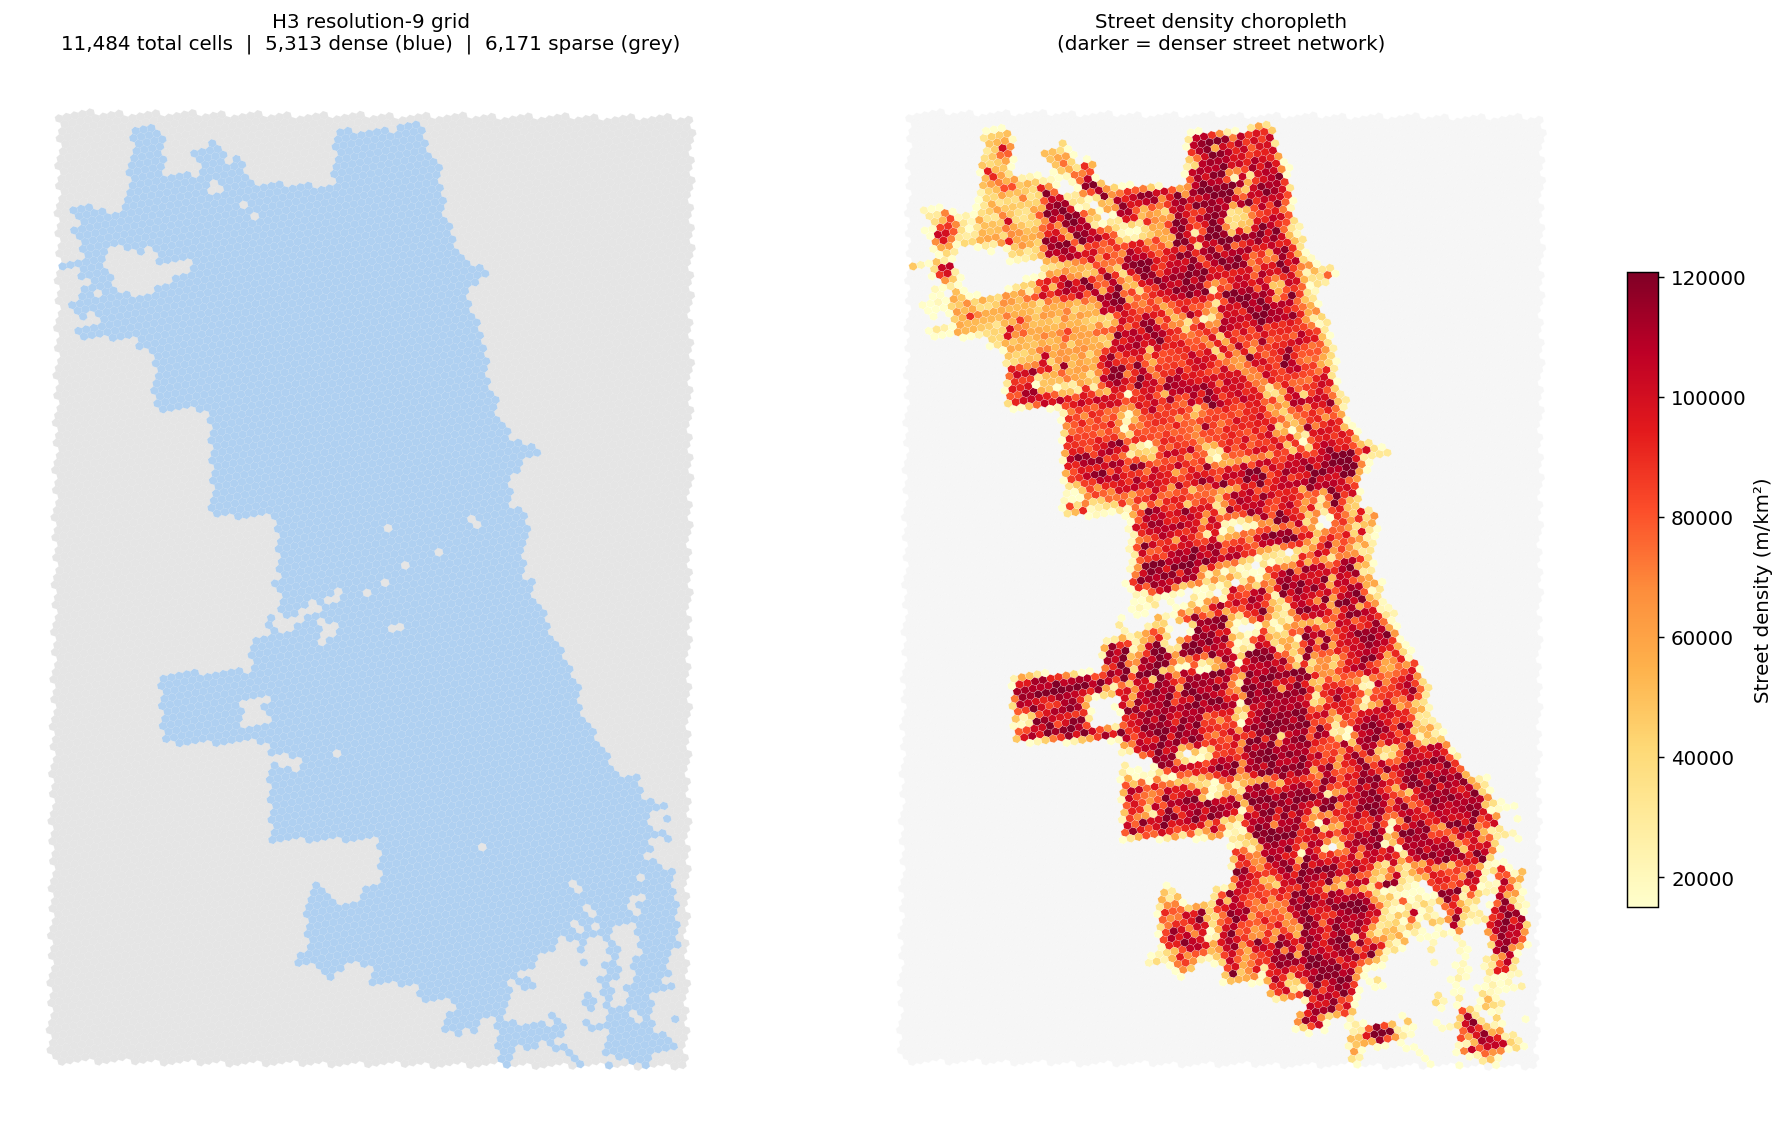

Expected: Loop area (downtown) should be darkest. Far South/West should be lighter.


In [45]:
fig, axes = plt.subplots(1, 2, figsize=(15, 9))

# Left: dense vs sparse
ax = axes[0]
gdf[gdf['data_sparse'] == 0].plot(ax=ax, color=BLUE, alpha=0.4, linewidth=0.1, edgecolor='white')
gdf[gdf['data_sparse'] == 1].plot(ax=ax, color='#AAAAAA', alpha=0.3, linewidth=0.1, edgecolor='white')
ax.set_axis_off()
ax.set_title(f'H3 resolution-{cfg.h3.resolution} grid\n'
             f'{len(gdf):,} total cells  |  '
             f'{len(dense):,} dense (blue)  |  '
             f'{int(gdf["data_sparse"].sum()):,} sparse (grey)', fontsize=11)

# Right: street density choropleth
ax2 = axes[1]
dense.plot(
    column='street_density_m_per_km2',
    ax=ax2,
    cmap='YlOrRd',
    linewidth=0.1,
    edgecolor='white',
    legend=True,
    legend_kwds={'label': 'Street density (m/km²)', 'shrink': 0.6},
    vmin=dense['street_density_m_per_km2'].quantile(0.05),
    vmax=dense['street_density_m_per_km2'].quantile(0.95),
)
gdf[gdf['data_sparse'] == 1].plot(ax=ax2, color='#EEEEEE', alpha=0.5, linewidth=0.1)
ax2.set_axis_off()
ax2.set_title('Street density choropleth\n(darker = denser street network)', fontsize=11)

plt.tight_layout()
fig.savefig(FIGURES_DIR / 'w02_h3_grid_coverage.png', dpi=150, bbox_inches='tight')
plt.show()
print('Expected: Loop area (downtown) should be darkest. Far South/West should be lighter.')

## 3. Feature Distribution Overview

Quick distribution check for all 16 features on dense cells only.

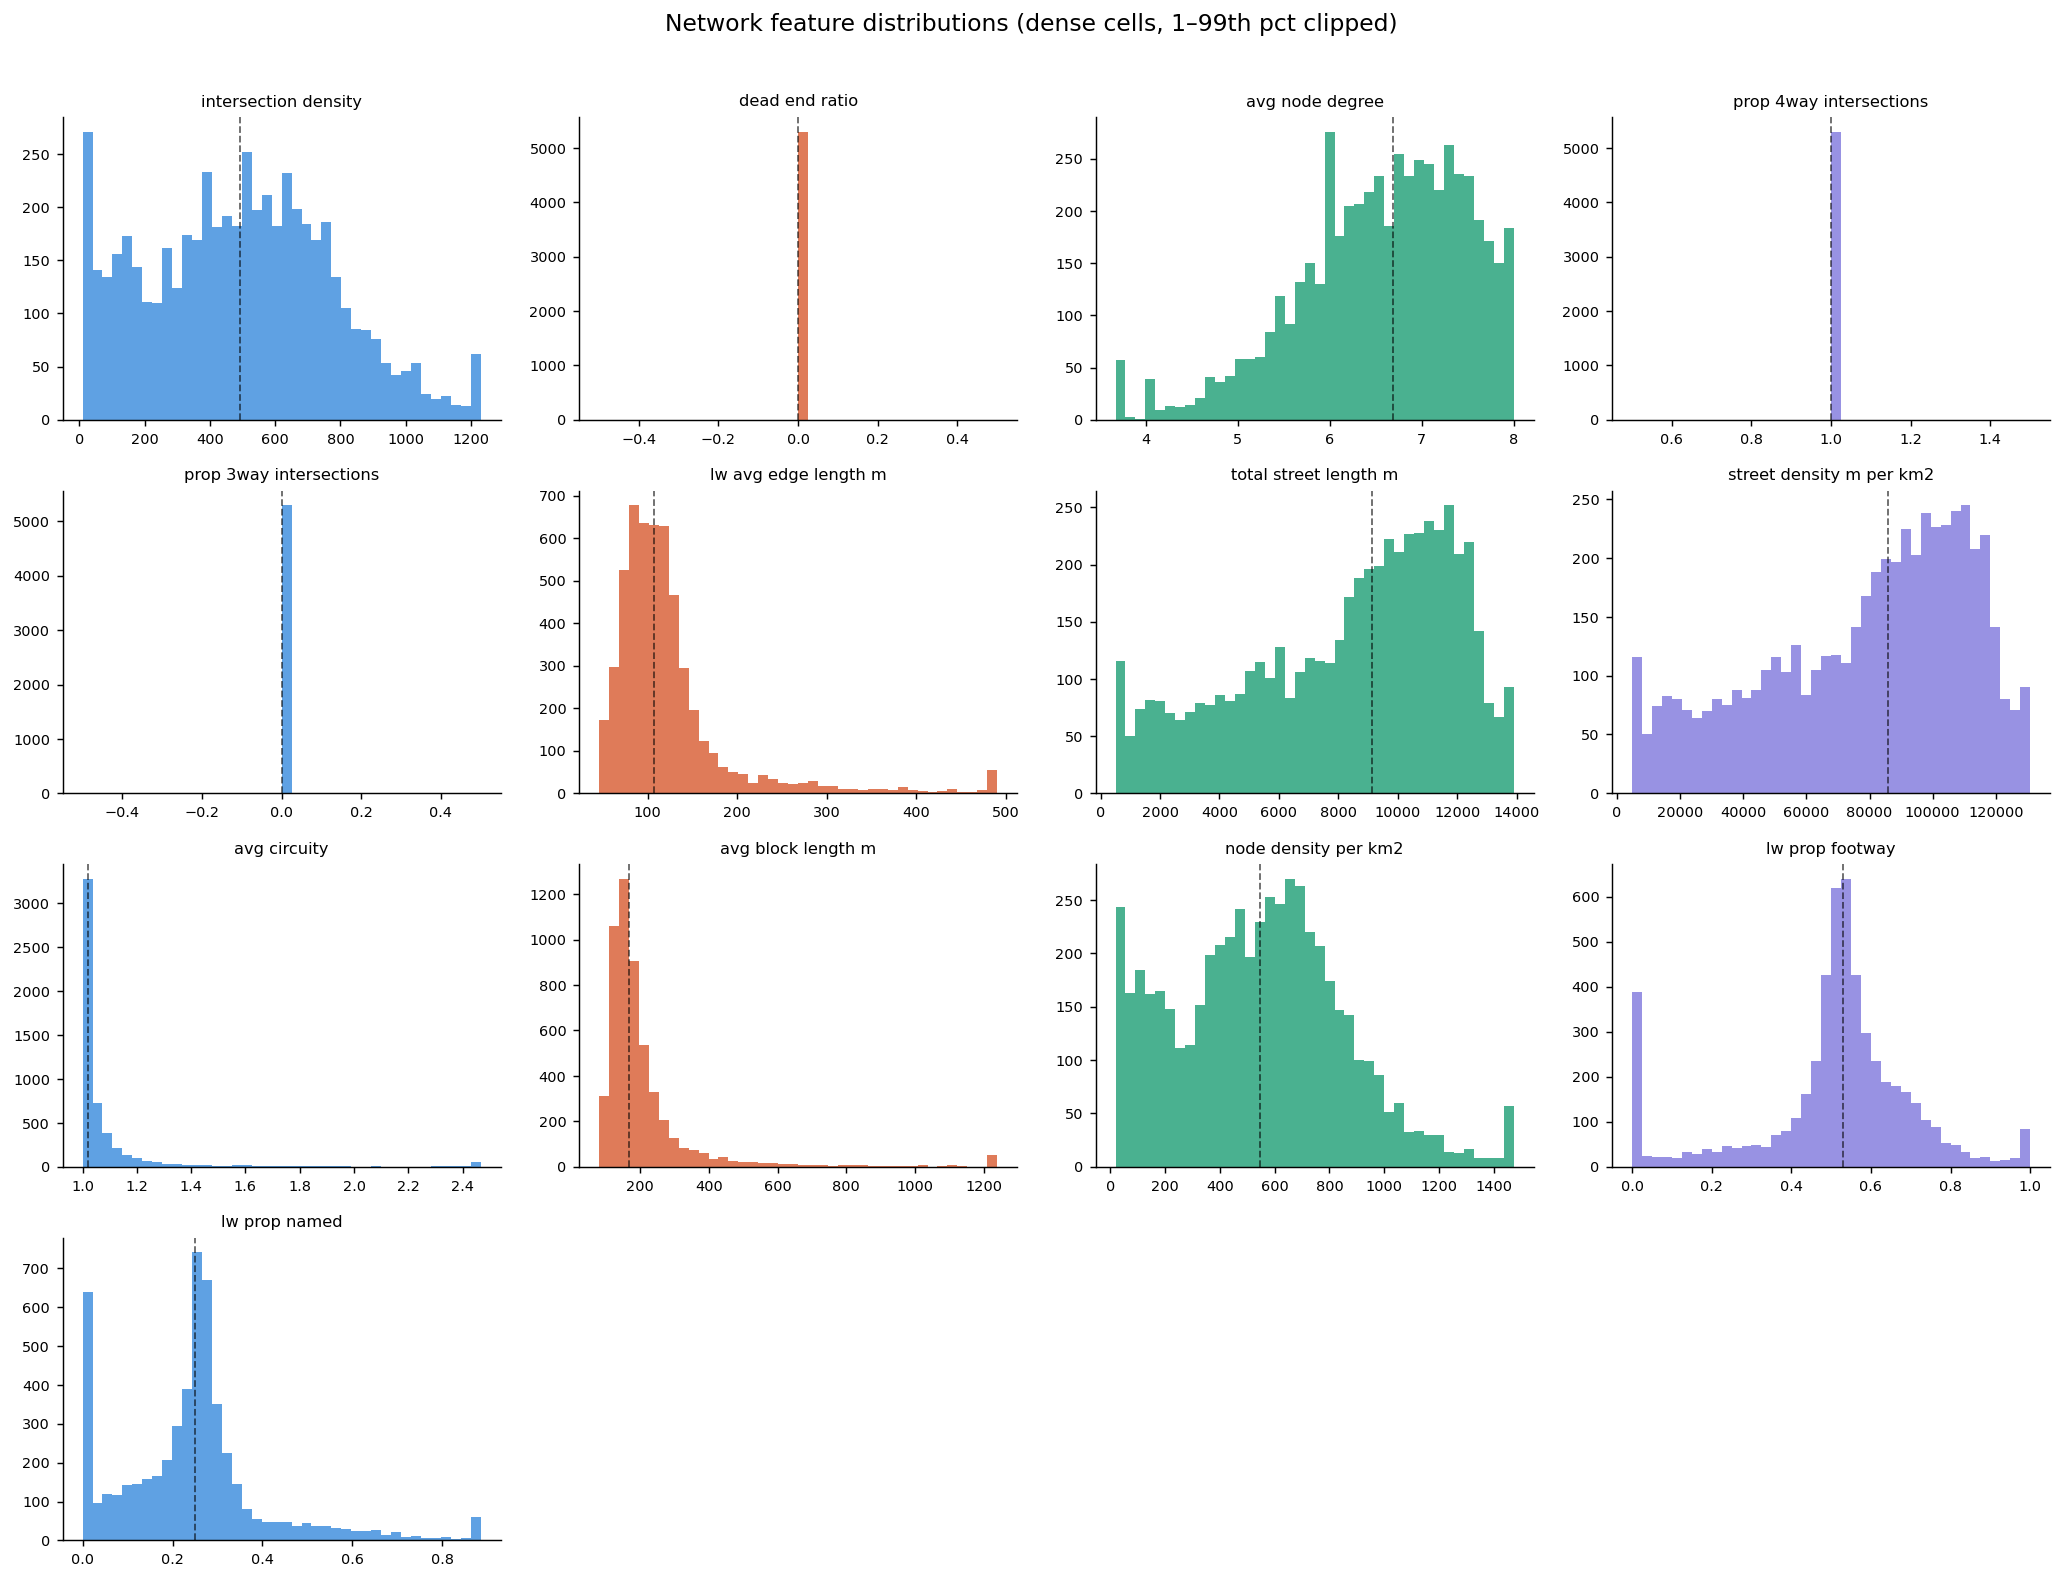

In [46]:
feature_cols = [
    'intersection_density', 'dead_end_ratio', 'avg_node_degree',
    'prop_4way_intersections', 'prop_3way_intersections',
    'lw_avg_edge_length_m', 'median_edge_length_m', 'total_street_length_m',
    'street_density_m_per_km2', 'edge_length_std', 'avg_circuity',
    'avg_block_length_m', 'node_density_per_km2',
    'lw_prop_footway', 'prop_residential', 'lw_prop_named',
]
feature_cols = [c for c in feature_cols if c in dense.columns]

fig, axes = plt.subplots(4, 4, figsize=(16, 12))
axes = axes.flatten()

colors = [BLUE, CORAL, TEAL, PURPLE] * 4

for i, col in enumerate(feature_cols):
    ax = axes[i]
    series = dense[col].dropna()
    # Clip to 1st–99th percentile to suppress outlier influence on plot
    clipped = series.clip(series.quantile(0.01), series.quantile(0.99))
    ax.hist(clipped, bins=40, color=colors[i], alpha=0.8, edgecolor='none')
    ax.axvline(series.median(), color='black', linewidth=1, linestyle='--', alpha=0.6)
    ax.set_title(col.replace('_', ' '), fontsize=9)
    ax.set_ylabel('')
    ax.tick_params(labelsize=8)

# Hide unused axes
for j in range(len(feature_cols), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Network feature distributions (dense cells, 1–99th pct clipped)',
             fontsize=13, y=1.01)
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'w02_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Correlation Matrix

Identify highly correlated feature pairs (|r| > 0.85) that may cause multicollinearity issues in the linear baseline. Note them — but don't drop them yet.

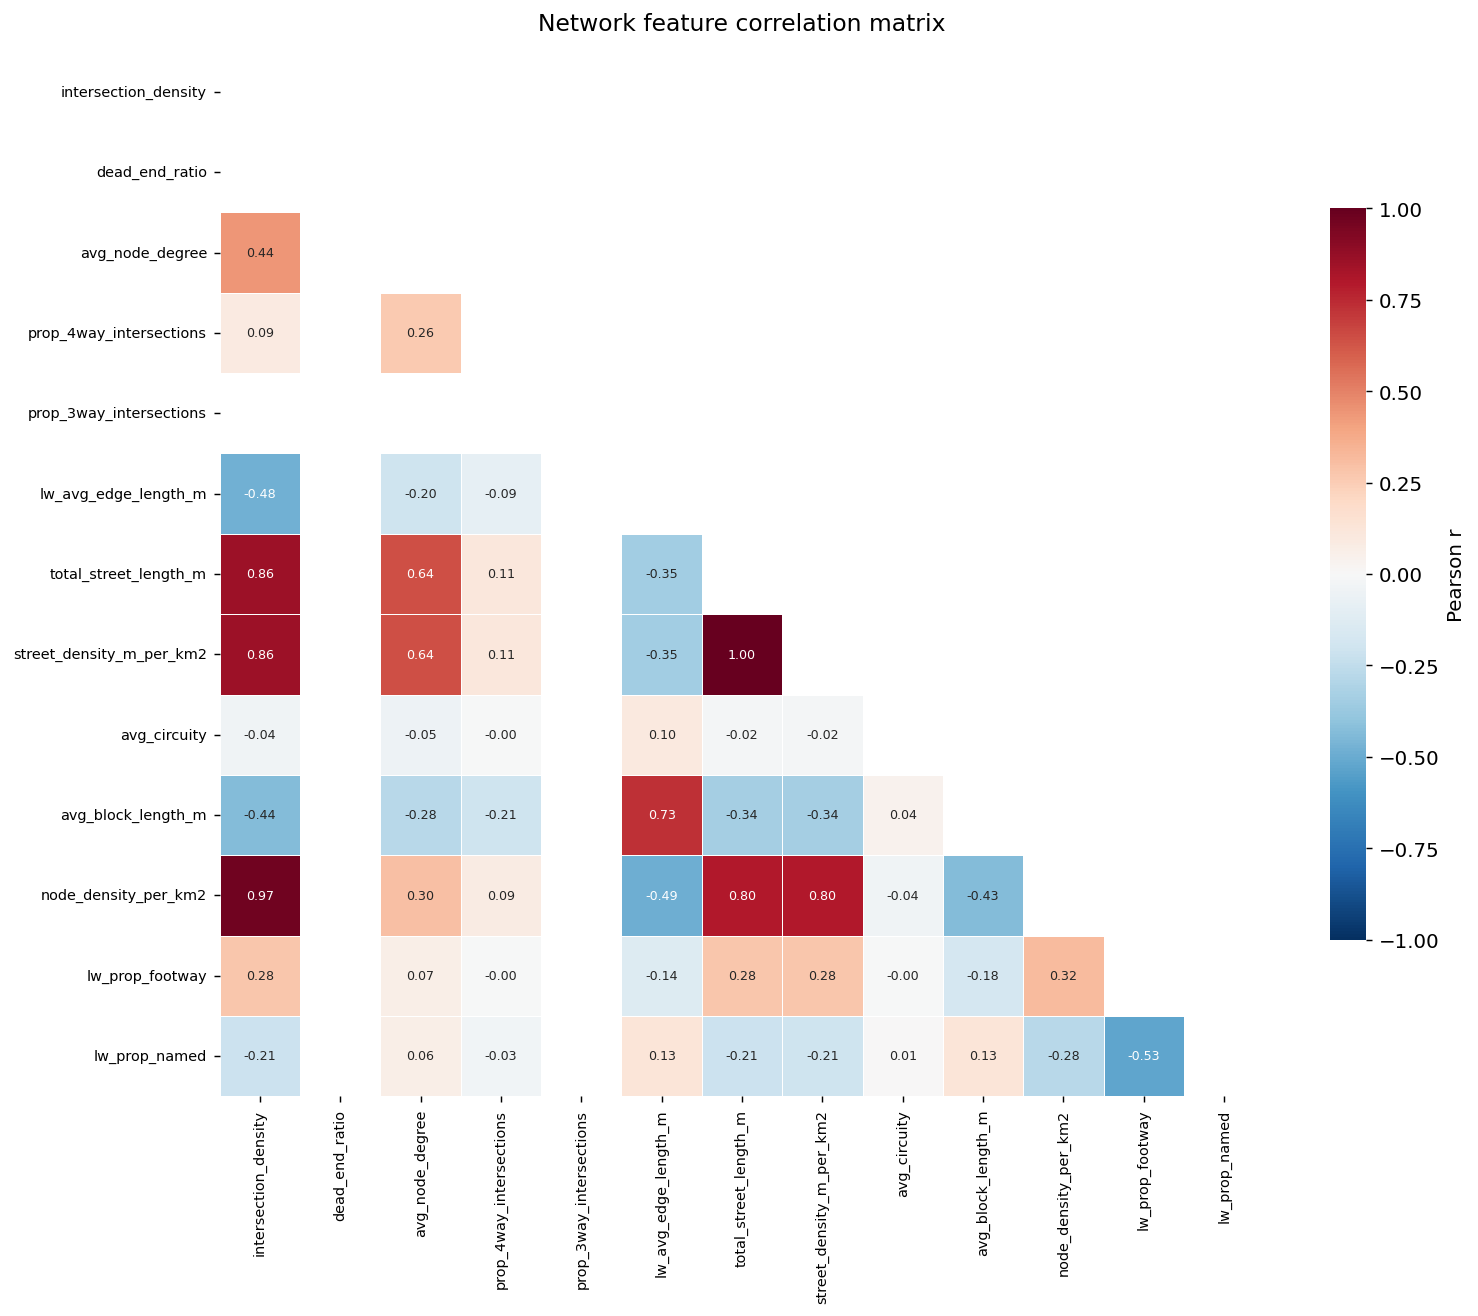


Highly correlated pairs (|r| > 0.85) — note for Week 5 QA:
  street_density_m_per_km2  ↔  total_street_length_m  (r=1.000)
  intersection_density  ↔  node_density_per_km2  (r=0.974)
  intersection_density  ↔  total_street_length_m  (r=0.856)
  intersection_density  ↔  street_density_m_per_km2  (r=0.856)


In [47]:
corr = dense[feature_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))  # show lower triangle only
sns.heatmap(
    corr, mask=mask, ax=ax,
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.3,
    annot=True, fmt='.2f', annot_kws={'size': 7},
    cbar_kws={'shrink': 0.7, 'label': 'Pearson r'},
)
ax.set_title('Network feature correlation matrix', fontsize=13, pad=12)
ax.tick_params(labelsize=8)
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'w02_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Flag pairs with |r| > 0.85
high_corr = [
    (r, c, corr.loc[r, c])
    for r in corr.index for c in corr.columns
    if r < c and abs(corr.loc[r, c]) > 0.85
]
if high_corr:
    print('\nHighly correlated pairs (|r| > 0.85) — note for Week 5 QA:')
    for r, c, v in sorted(high_corr, key=lambda x: -abs(x[2])):
        print(f'  {r}  ↔  {c}  (r={v:.3f})')
else:
    print('No pairs with |r| > 0.85 — good feature diversity.')

## 5. Key Feature Choropleths

Map 4 interpretable features. These should show clear geographic patterns consistent with what you know about Chicago.

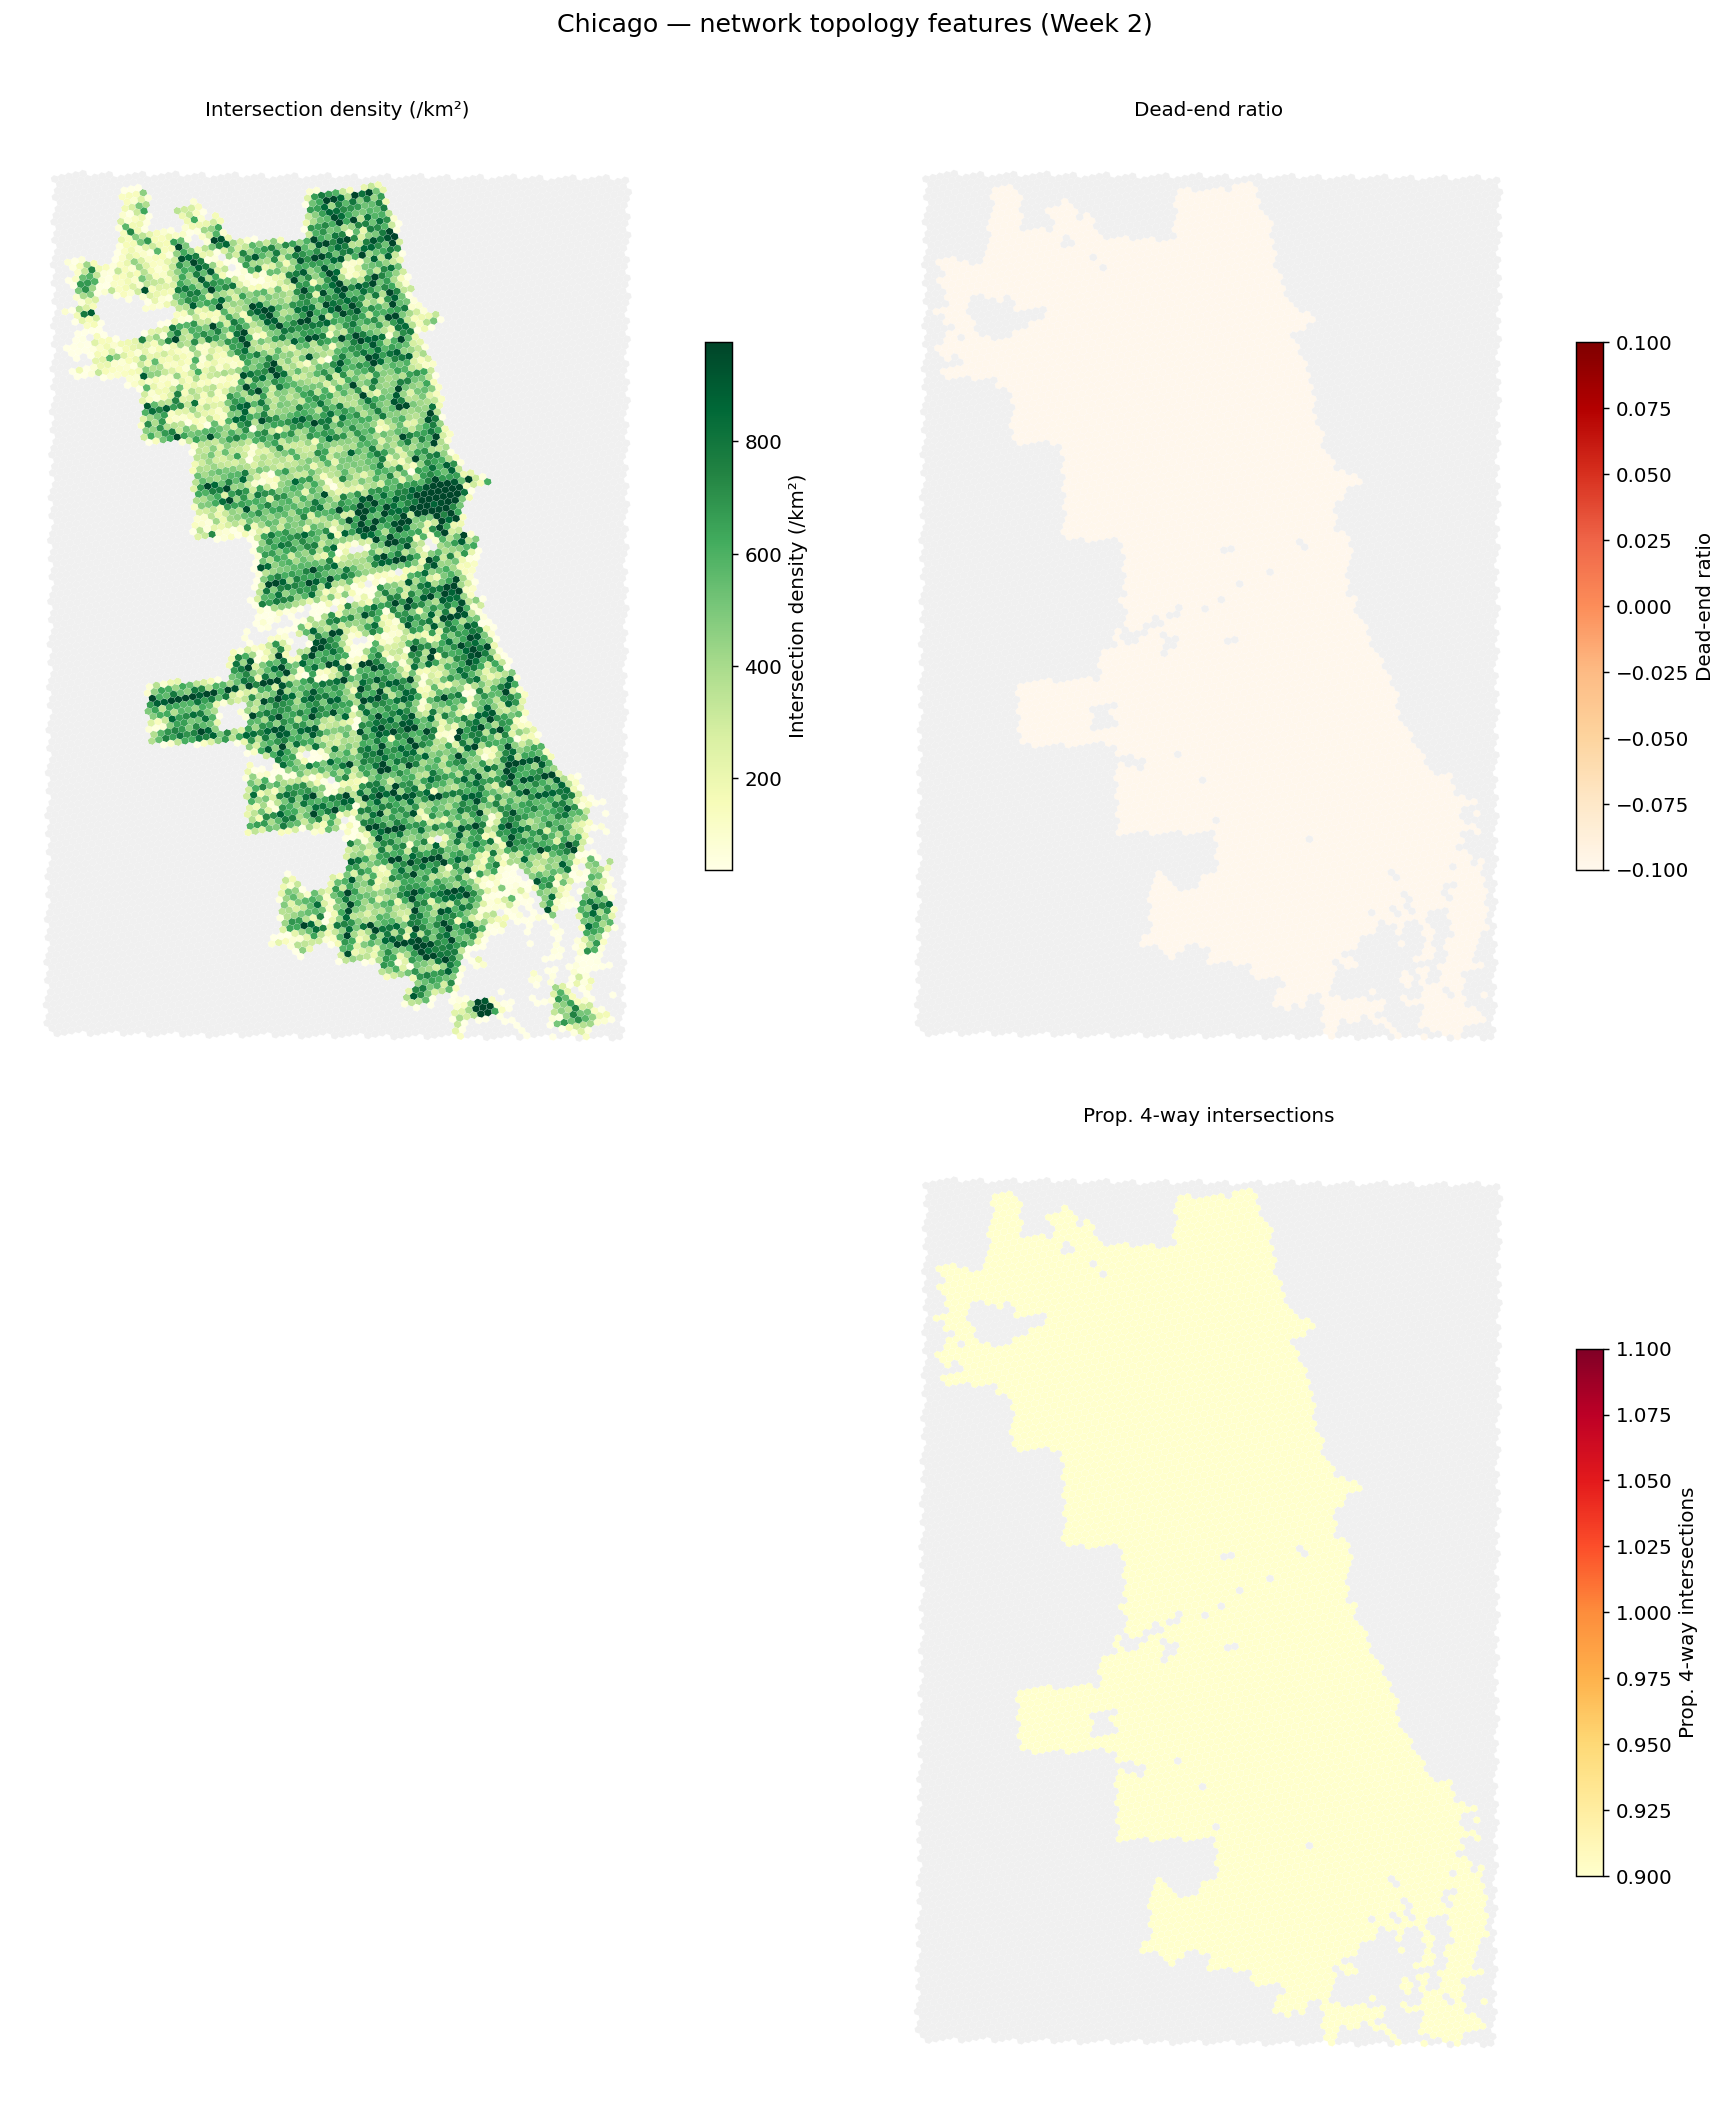


Interpretation checks:
  intersection_density   → highest in Loop / Near North Side
  dead_end_ratio         → highest in residential cul-de-sac areas (far NW/SW)
  avg_edge_length_m      → shortest in dense downtown grid (~80m)
  prop_4way_intersections→ highest in Chicago's famous grid neighbourhoods



In [48]:
plot_features = [
    ('intersection_density',   'Intersection density (/km²)',   'YlGn'),
    ('dead_end_ratio',         'Dead-end ratio',                'OrRd'),
    ('avg_edge_length_m',      'Avg edge length (m)',           'PuBu'),
    ('prop_4way_intersections','Prop. 4-way intersections',     'YlOrRd'),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 16))
axes = axes.flatten()

for ax, (col, label, cmap) in zip(axes, plot_features):
    if col not in dense.columns:
        ax.set_visible(False)
        continue
    series = dense[col].dropna()
    vmin = series.quantile(0.05)
    vmax = series.quantile(0.95)
    dense.plot(
        column=col, ax=ax, cmap=cmap,
        linewidth=0.05, edgecolor='white',
        legend=True,
        legend_kwds={'shrink': 0.55, 'label': label},
        vmin=vmin, vmax=vmax, missing_kwds={'color': '#F0F0F0'},
    )
    gdf[gdf['data_sparse'] == 1].plot(ax=ax, color='#F0F0F0', linewidth=0)
    ax.set_axis_off()
    ax.set_title(label, fontsize=11, pad=6)

fig.suptitle('Chicago — network topology features (Week 2)', fontsize=14, y=1.01)
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'w02_feature_choropleths.png', dpi=150, bbox_inches='tight')
plt.show()

print("""
Interpretation checks:
  intersection_density   → highest in Loop / Near North Side
  dead_end_ratio         → highest in residential cul-de-sac areas (far NW/SW)
  avg_edge_length_m      → shortest in dense downtown grid (~80m)
  prop_4way_intersections→ highest in Chicago's famous grid neighbourhoods
""")

## 6. Neighbourhood Comparison

Compare feature profiles between 3 known areas:
- **The Loop** — dense, highly walkable grid
- **Lincoln Park** — mixed walkable residential
- **Hegewisch** — sparse, car-dependent far SE

['h3_index', 'geometry', 'centroid_x', 'centroid_y', 'centroid_lat', 'centroid_lng', 'n_real_edges', 'n_nodes_in_hex', 'total_street_length_m', 'data_sparse', 'intersection_density', 'dead_end_ratio', 'avg_node_degree', 'prop_4way_intersections', 'prop_3way_intersections', 'node_density_per_km2', 'avg_circuity', 'lw_avg_edge_length_m', 'street_density_m_per_km2', 'edge_length_cv', 'avg_block_length_m', 'lw_prop_footway', 'lw_prop_residential', 'lw_prop_alley', 'lw_prop_road_fragment', 'lw_prop_named', 'lw_prop_oneway', 'lw_avg_speed_regime', 'lw_prop_regime_5', 'lw_prop_regime_3plus', 'lw_prop_measured_speed', 'prop_has_speed_limit', 'prop_is_bridge', 'prop_is_tunnel']
['intersection_density', 'dead_end_ratio', 'avg_node_degree', 'prop_4way_intersections', 'prop_3way_intersections', 'lw_avg_edge_length_m', 'total_street_length_m', 'street_density_m_per_km2', 'avg_circuity', 'avg_block_length_m', 'node_density_per_km2', 'lw_prop_footway', 'lw_prop_named']


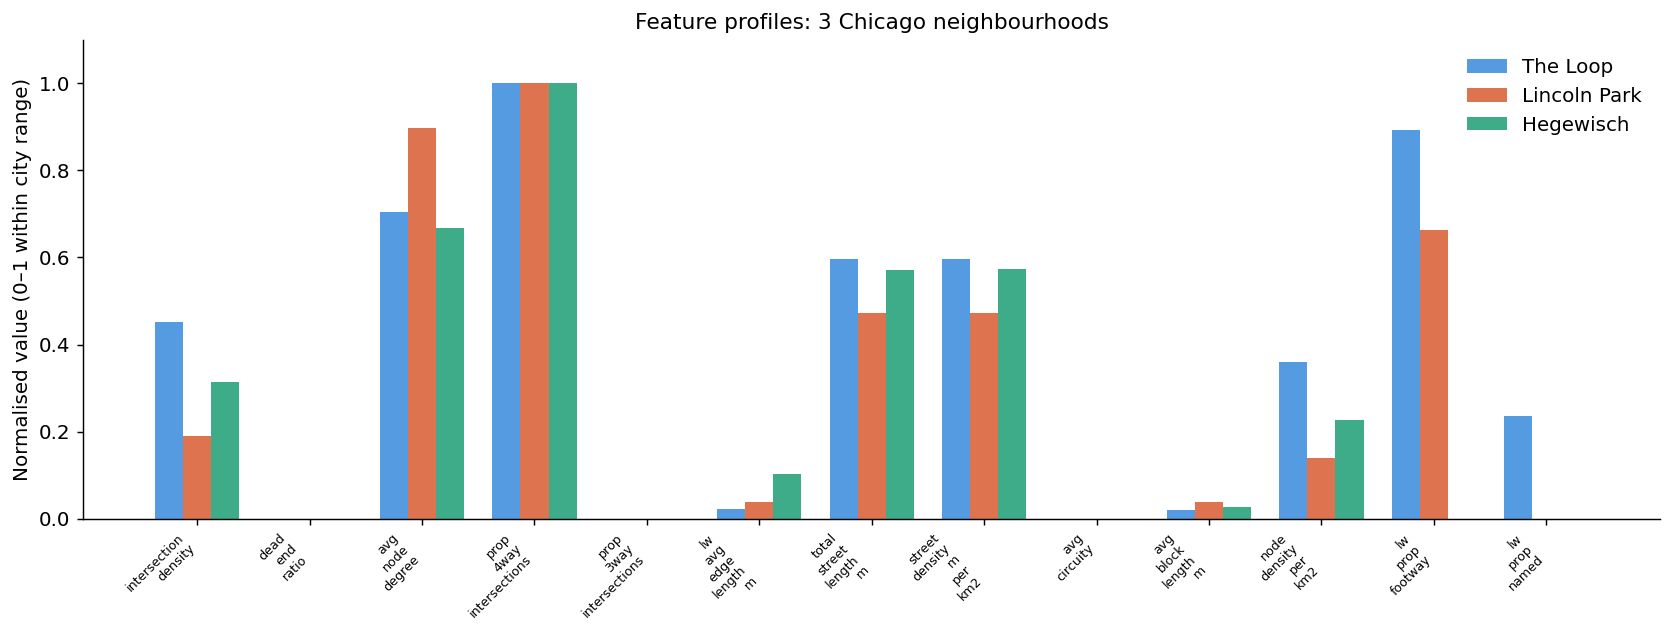


Raw feature values:
             intersection_density dead_end_ratio lw_avg_edge_length_m prop_4way_intersections
The Loop               978.252546            0.0            52.688632                     1.0
Lincoln Park           413.617357            0.0            82.649532                     1.0
Hegewisch              679.978525            0.0           204.347681                     1.0


In [49]:
import h3 as h3lib

SPOTS = {
    'The Loop':      (41.8827, -87.6298),
    'Lincoln Park':  (41.9214, -87.6513),
    'Hegewisch':     (41.6497, -87.5525),
}

profiles = {}
for name, (lat, lng) in SPOTS.items():
    h3_idx = h3lib.latlng_to_cell(lat, lng, cfg.h3.resolution)
    row = gdf[gdf['h3_index'] == h3_idx]
    if len(row) == 0:
        print(f'  {name}: hex {h3_idx} not found in grid — try nearby coords')
        continue
    profiles[name] = row.iloc[0][feature_cols]

if profiles:
    print(gdf.columns.tolist())
    print(feature_cols)
    profiles_df = pd.DataFrame(profiles).T

    # Normalise each feature to [0,1] for radar-style comparison
    norm_df = (profiles_df - dense[feature_cols].min()) / \
              (dense[feature_cols].max() - dense[feature_cols].min())

    fig, ax = plt.subplots(figsize=(13, 5))
    x = np.arange(len(feature_cols))
    width = 0.25
    palette = [BLUE, CORAL, TEAL]

    for i, (name, row) in enumerate(norm_df.iterrows()):
        ax.bar(x + i*width, row.values, width, label=name,
               color=palette[i], alpha=0.85, edgecolor='none')

    ax.set_xticks(x + width)
    ax.set_xticklabels([c.replace('_', '\n') for c in feature_cols],
                       fontsize=7, rotation=45, ha='right')
    ax.set_ylabel('Normalised value (0–1 within city range)')
    ax.set_title('Feature profiles: 3 Chicago neighbourhoods', fontsize=12)
    ax.legend(frameon=False)
    ax.set_ylim(0, 1.1)

    plt.tight_layout()
    fig.savefig(FIGURES_DIR / 'w02_neighbourhood_profiles.png', dpi=150, bbox_inches='tight')
    plt.show()

    print('\nRaw feature values:')
    print(profiles_df[['intersection_density','dead_end_ratio',
                        'lw_avg_edge_length_m','prop_4way_intersections']].round(3).to_string())

## 7. Week 2 Final Checklist

In [50]:
checks = []

def check(label, condition, fix=''):
    checks.append(('PASS' if condition else 'FAIL', label, fix))

# File existence
check('network_features.parquet exists', feat_path.exists())

# Grid size
check('H3 grid has >= 10,000 cells', len(gdf) >= 10_000,
      fix='Grid too small — check city_config.yml bounding box')
check('Dense cells >= 70% of grid', len(dense)/len(gdf) >= 0.70,
      fix='Too many sparse cells — check OSMnx network coverage')

# Feature completeness on dense cells
check('intersection_density NaN < 5%',
      dense['intersection_density'].isna().mean() < 0.05)
check('avg_edge_length_m NaN < 5%',
      dense['lw_avg_edge_length_m'].isna().mean() < 0.05)
check('lw_prop_footway column present', 'lw_prop_footway' in dense.columns)
check('lw_prop_named column present', 'lw_prop_named' in dense.columns)

# Sanity ranges
med_int = dense['intersection_density'].median()
check(f'Median intersection density 20–200/km² (got {med_int:.0f})',
      20 < med_int < 200,
      fix='Intersection density out of expected range — check area units (should be km²)')

med_len = dense['lw_avg_edge_length_m'].median()
check(f'Median edge length 50–250m (got {med_len:.0f}m)',
      50 < med_len < 250,
      fix='Edge length suspicious — check CRS is metric (EPSG:26916)')

# Output figures
n_figs = len(list(FIGURES_DIR.glob('w02_*.png')))
check(f'At least 4 w02 figures saved (found {n_figs})', n_figs >= 4)

# CRS
check('GDF CRS is EPSG:26916', gdf.crs.to_epsg() == 26916)

print('\nWEEK 2 FINAL CHECKLIST')
print('─' * 60)
all_pass = True
for status, label, fix in checks:
    icon = '✓' if status == 'PASS' else '✗'
    print(f'  {icon}  {label}')
    if status == 'FAIL':
        all_pass = False
        if fix:
            print(f'       → {fix}')
print('─' * 60)
if all_pass:
    print('  All checks passed. Commit Week 2 and proceed to Week 3.')
    print('  Next: python -m src.features.feature_store  (merge into master)')
else:
    print('  Fix the failing checks before committing.')


WEEK 2 FINAL CHECKLIST
────────────────────────────────────────────────────────────
  ✓  network_features.parquet exists
  ✓  H3 grid has >= 10,000 cells
  ✗  Dense cells >= 70% of grid
       → Too many sparse cells — check OSMnx network coverage
  ✓  intersection_density NaN < 5%
  ✓  avg_edge_length_m NaN < 5%
  ✓  lw_prop_footway column present
  ✓  lw_prop_named column present
  ✗  Median intersection density 20–200/km² (got 491)
       → Intersection density out of expected range — check area units (should be km²)
  ✓  Median edge length 50–250m (got 107m)
  ✓  At least 4 w02 figures saved (found 5)
  ✓  GDF CRS is EPSG:26916
────────────────────────────────────────────────────────────
  Fix the failing checks before committing.
